# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ana Sittah Rosyidah, S.ST.
- Email: ana5210@guru.smk.belajar.id

- Id Dicoding:https://www.dicoding.com/users/ana_sittah_rosyidah/academies

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import sklearn
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

*   Memprediksi apakah karyawan akan keluar (Attrition)
*   Mengidentifikasi faktor penyebab attrition

#### Konstan / tidak berguna:
*   EmployeeCount (selalu 1)
*   Over18 (selalu "Y")
*   StandardHours (selalu 80)

#### fitur penting:
*   Target (label):
    - Attrition → (1 = keluar, kosong/0 = tidak keluar)
*   Numerik:
    - Age, DailyRate, MonthlyIncome, DistanceFromHome
    - TotalWorkingYears, YearsAtCompany, dll
*   Kategorikal:
    - BusinessTravel, Department, Gender, JobRole
    - MaritalStatus, OverTime, dll

In [55]:
df = pd.read_csv("employee/employee_data.csv")

In [56]:
df.head(10)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
5,6,29,NaN,Travel_Rarely,352,Human Resources,6,1,Medical,1,...,4,80,0,1,3,3,1,0,0,0
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,...,3,80,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,...,4,80,1,24,2,3,5,2,1,4
8,9,36,0.0,Travel_Frequently,635,Research & Development,18,1,Medical,1,...,1,80,0,8,2,3,8,1,1,7
9,10,32,0.0,Travel_Rarely,1018,Research & Development,3,2,Life Sciences,1,...,4,80,0,10,6,3,7,7,7,7


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

## Data Preparation / Preprocessing

Bagian 1: Data Understanding & Cleaning

In [40]:
import pandas as pd
import numpy as np

# 1. Load Data
# Pastikan file CSV awal sudah dimuat
# df = pd.read_csv('link_atau_path_file_anda')

print("--- Pembersihan Data Awal ---")

# 2. Hapus kolom konstan sesuai kriteria Data Understanding
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, axis=1, inplace=True, errors='ignore')

# 3. Handling Missing Values (NaN)
print(f"Jumlah NaN sebelum: {df.isnull().sum().sum()}")
df.dropna(inplace=True)

# 4. Memastikan Target (Attrition) menjadi Numerik (0 dan 1)
# Ini krusial agar bisa dihitung rata-ratanya (mean) di tahap EDA
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

df['Attrition'] = df['Attrition'].fillna(0).astype(int)

# 5. Simpan data bersih untuk dashboard
df.to_csv('dashboard/employee_data_cleaned.csv', index=False)

print(f"✅ Data bersih disimpan. Ukuran: {df.shape}")
print(f"Distribusi Target Attrition:\n{df['Attrition'].value_counts()}")

--- Pembersihan Data Awal ---
Jumlah NaN sebelum: 0
✅ Data bersih disimpan. Ukuran: (1058, 32)
Distribusi Target Attrition:
Attrition
0    879
1    179
Name: count, dtype: int64


Bagian 2: Exploratory Data Analysis (EDA)

2.1. Rangkuman Statistik

In [41]:
# Melihat gambaran besar data (Mean, Median, Max, Min)
print("--- Rangkuman Statistik Dataset ---")
display(df.describe(include="all"))

--- Rangkuman Statistik Dataset ---


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1058.000000,1058.000000,1058.000000,1058,1058.000000,1058,1058.000000,1058.000000,1058,1058.000000,...,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.00000,1058.000000,1058.000000
unique,NaN,NaN,NaN,3,NaN,3,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,746,NaN,701,NaN,NaN,436,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,736.656900,37.055766,0.169187,NaN,809.542533,NaN,8.978261,2.879017,NaN,2.712665,...,3.150284,2.726843,0.762760,11.435728,2.769376,2.763705,7.065217,4.26087,2.203214,4.142722
std,427.440538,9.410421,0.375094,NaN,408.478049,NaN,8.040608,1.031442,NaN,1.092959,...,0.357518,1.090970,0.837537,8.016429,1.302689,0.707392,6.265227,3.61747,3.266948,3.599044
min,2.000000,18.000000,0.000000,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,364.250000,30.000000,0.000000,NaN,465.250000,NaN,2.000000,2.000000,NaN,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.00000,0.000000,2.000000
50%,731.500000,36.000000,0.000000,NaN,817.500000,NaN,7.000000,3.000000,NaN,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.00000,1.000000,3.000000
75%,1117.750000,43.000000,0.000000,NaN,1168.500000,NaN,13.000000,4.000000,NaN,4.000000,...,3.000000,4.000000,1.000000,16.000000,3.000000,3.000000,9.000000,7.00000,3.000000,7.000000


2.2. Membuat Helper Function (Efisiensi Kode)

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Fungsi untuk cek fitur kategori (Misal: JobRole, OverTime) vs Attrition
def plot_categorical_attrition(features, df):
    fig, ax = plt.subplots(len(features), 1, figsize=(12, 6 * len(features)))
    for i, feature in enumerate(features):
        sns.countplot(data=df, x=feature, hue="Attrition", ax=ax[i], palette="viridis")
        ax[i].set_title(f"Analisis Attrition berdasarkan {feature}", fontsize=14)
        ax[i].legend(title='Attrition', labels=['Stay (0)', 'Leave (1)'])
        plt.setp(ax[i].get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

# Fungsi untuk cek fitur angka (Misal: Gaji, Usia) vs Attrition
def plot_numerical_attrition(features, df):
    fig, ax = plt.subplots(len(features), 1, figsize=(10, 5 * len(features)))
    for i, feature in enumerate(features):
        sns.boxplot(x="Attrition", y=feature, data=df, ax=ax[i], palette="Set2")
        ax[i].set_title(f"Perbandingan {feature} terhadap Attrition", fontsize=14)
    plt.tight_layout()
    plt.show()

2.3. Eksekusi Perbandingan Massal (Jawaban untuk Reviewer)

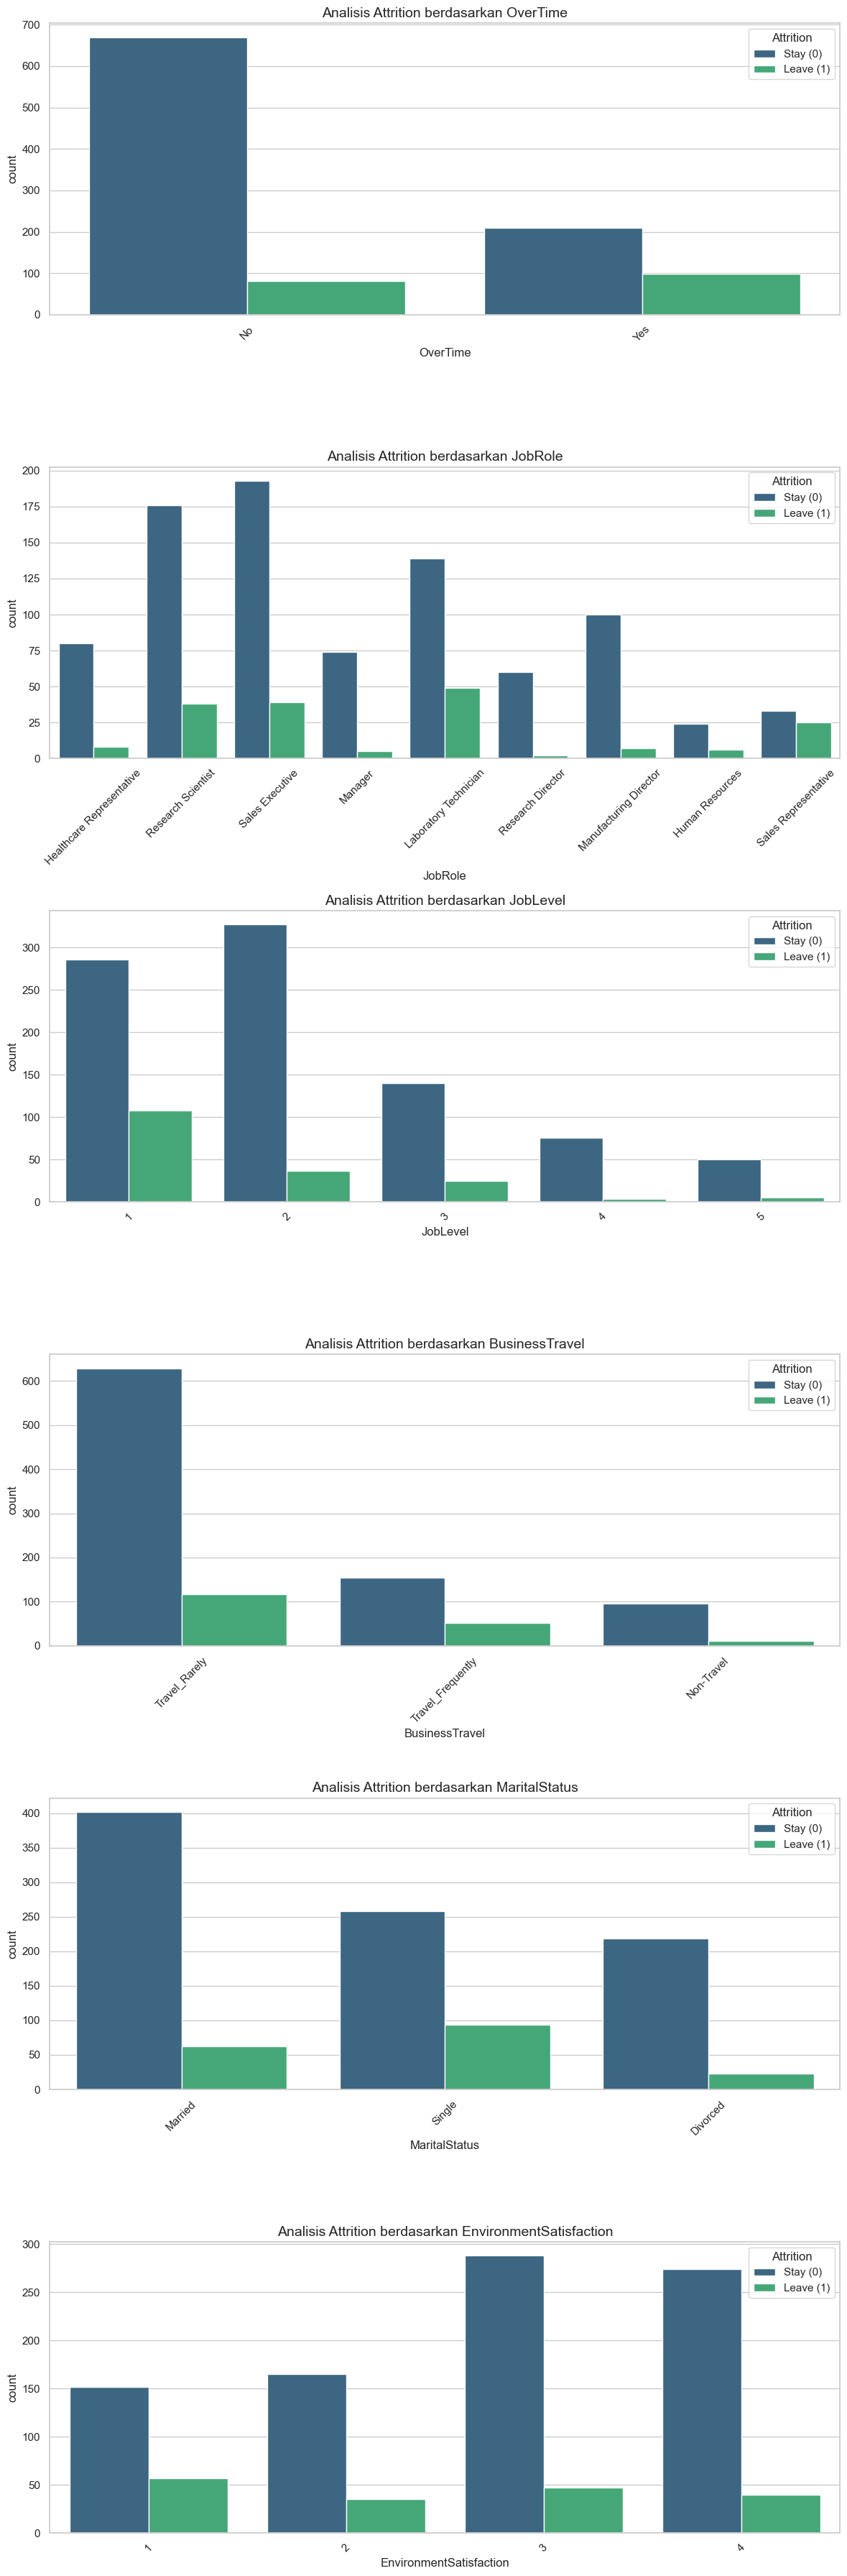

/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_9209/3869003661.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Attrition", y=feature, data=df, ax=ax[i], palette="Set2")
/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_9209/3869003661.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Attrition", y=feature, data=df, ax=ax[i], palette="Set2")
/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_9209/3869003661.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Attrition", y=feature, data=df, ax=ax[

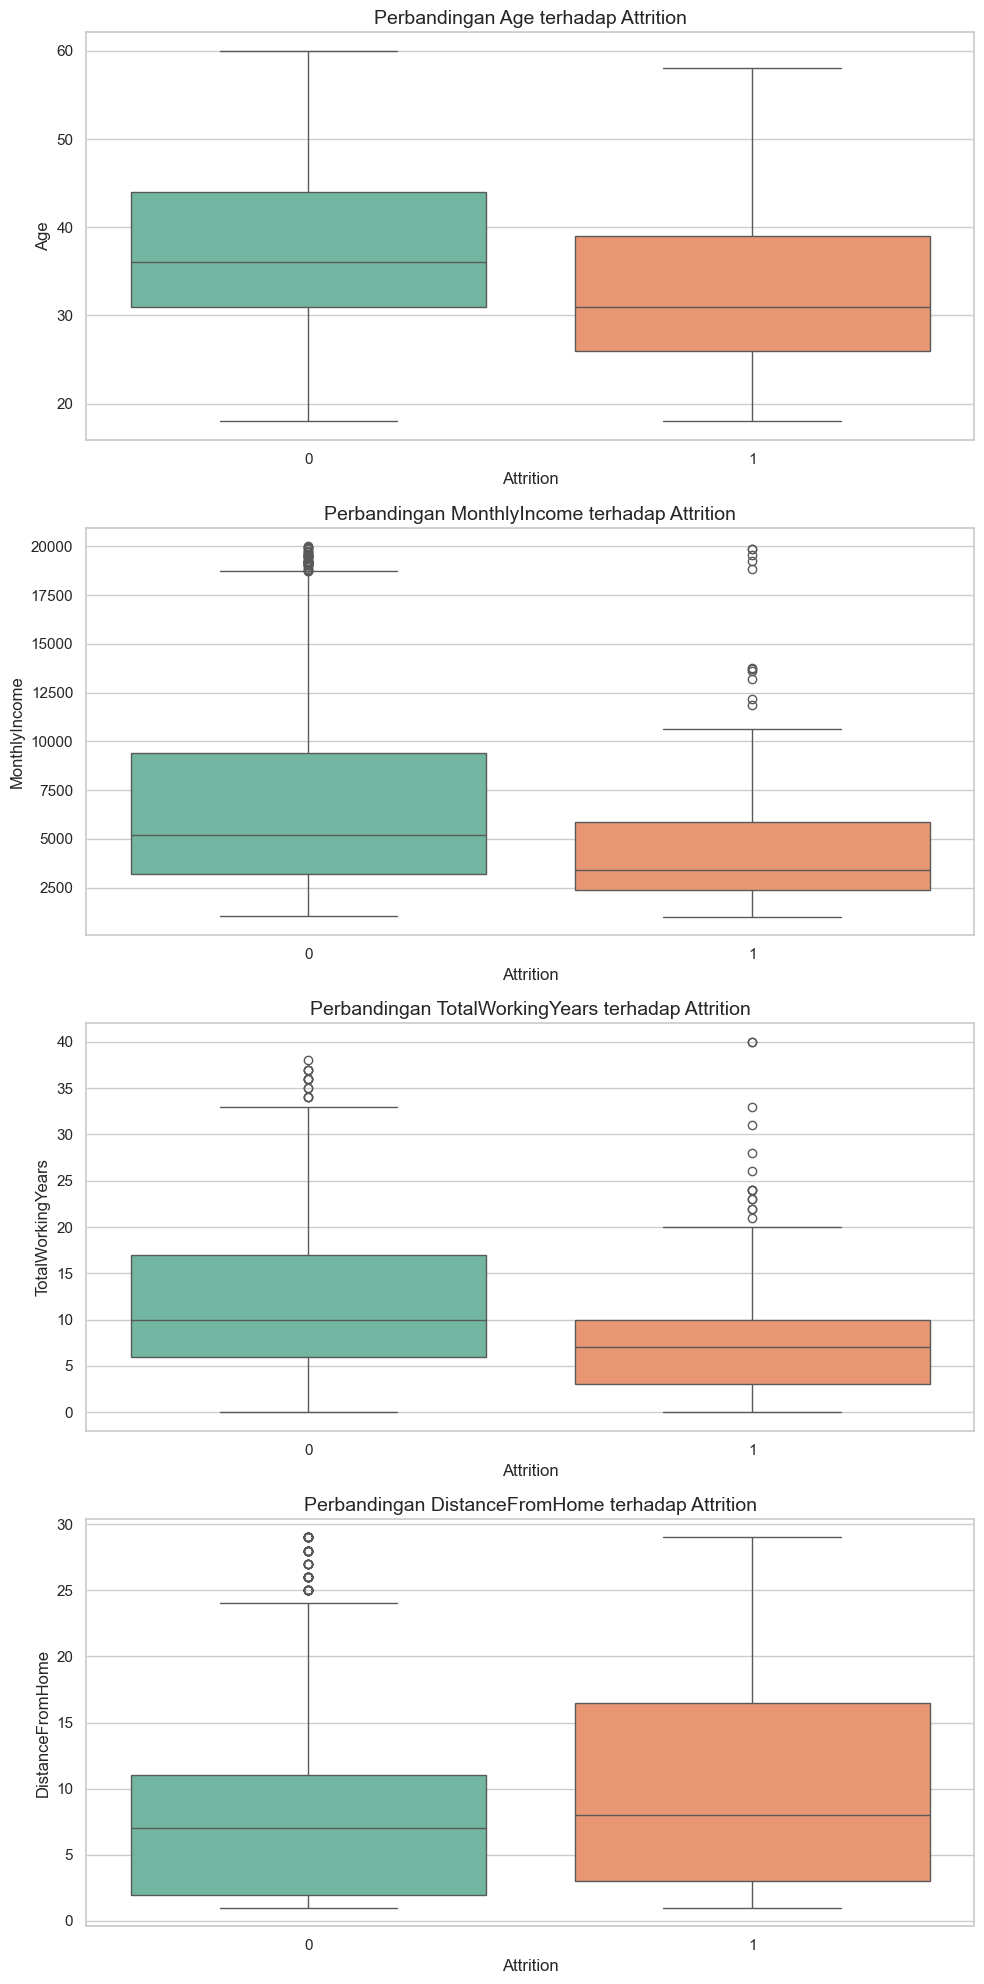

In [43]:
# Pilih faktor-faktor yang ingin dibandingkan
cat_cols = ["OverTime", "JobRole", "JobLevel", "BusinessTravel", "MaritalStatus", "EnvironmentSatisfaction"]
num_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "DistanceFromHome"]

# Jalankan visualisasi otomatis
plot_categorical_attrition(cat_cols, df)
plot_numerical_attrition(num_cols, df)

Bagian 3: Analisis Attrition Rate (Angka Pasti)

In [44]:
# Fungsi pembantu untuk menghitung persentase
def get_attrition_rate(df, column):
    return (df.groupby(column)['Attrition'].mean() * 100).round(2).sort_values(ascending=False)

print("=== PERSENTASE KARYAWAN KELUAR (%) ===")
print(f"\n1. Berdasarkan Posisi (Job Role):\n{get_attrition_rate(df, 'JobRole')}")
print(f"\n2. Berdasarkan Tingkat Kepuasan (Env Satisfaction):\n{get_attrition_rate(df, 'EnvironmentSatisfaction')}")
print(f"\n3. Berdasarkan Status Pernikahan:\n{get_attrition_rate(df, 'MaritalStatus')}")

=== PERSENTASE KARYAWAN KELUAR (%) ===

1. Berdasarkan Posisi (Job Role):
JobRole
Sales Representative         43.10
Laboratory Technician        26.06
Human Resources              20.00
Research Scientist           17.76
Sales Executive              16.81
Healthcare Representative     9.09
Manufacturing Director        6.54
Manager                       6.33
Research Director             3.23
Name: Attrition, dtype: float64

2. Berdasarkan Tingkat Kepuasan (Env Satisfaction):
EnvironmentSatisfaction
1    27.27
2    17.50
3    14.03
4    12.74
Name: Attrition, dtype: float64

3. Berdasarkan Status Pernikahan:
MaritalStatus
Single      26.70
Married     13.36
Divorced     9.50
Name: Attrition, dtype: float64


Bagian 4: Korelasi & Insight Tambahan

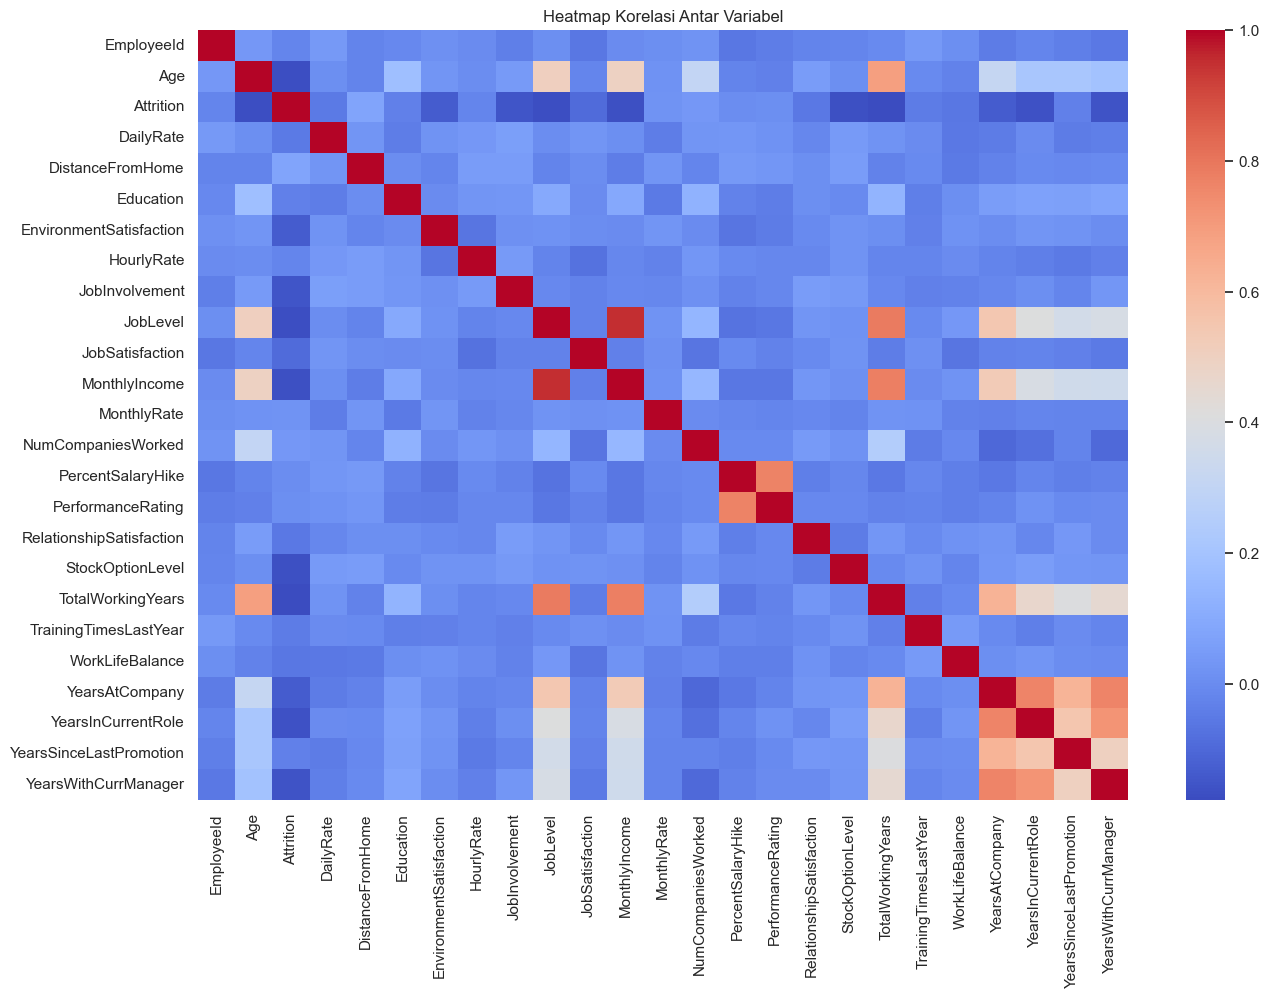

In [45]:
# Korelasi antar variabel numerik
plt.figure(figsize=(15, 10))
numerical_only = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_only.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

In [46]:
print("--- Jumlah NaN per Kolom ---")
print(df.isnull().sum())

--- Jumlah NaN per Kolom ---
EmployeeId                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int6

## Modeling

Melatih Model dengan Random Forest

Alur Modeling yang saya tulis secara teknis (urutan: Split $\rightarrow$ Scaling $\rightarrow$ SMOTE $\rightarrow$ Model).

In [ ]:
# Implementasi Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# A. Membagi Data 
# Test size 20% sudah cukup ideal untuk dataset ini
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# B. Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# C. Balancing Data dengan SMOTE
# Saya lakukan SMOTE hanya pada data training agar tidak terjadi data leakage
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# D. Membangun dan Melatih Model
# Saya menggunakan n_estimators=200 agar model lebih stabil dalam mengambil keputusan
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10, 
    random_state=42,
    class_weight='balanced' 
)

model.fit(X_train_res, y_train_res)
print("✅ Selesai! Model sudah dilatih dan siap untuk diuji.")

✅ Modeling selesai: Model telah dilatih dengan data yang diskalakan dan diseimbangkan.


## Evaluation


📋 HASIL EVALUASI MODEL
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       176
           1       0.64      0.39      0.48        36

    accuracy                           0.86       212
   macro avg       0.76      0.67      0.70       212
weighted avg       0.84      0.86      0.84       212

Skor Akurasi Keseluruhan: 85.85%


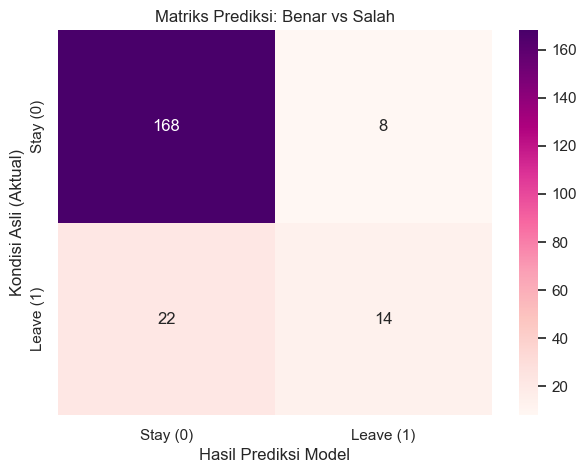

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prediksi pada Data Uji
y_pred = model.predict(X_test_scaled)

# 2. Menampilkan Metrik Evaluasi
print("\n" + "="*40)
print("📋 HASIL EVALUASI MODEL")
print("="*40)
print(classification_report(y_test, y_pred))
print(f"Skor Akurasi Keseluruhan: {accuracy_score(y_test, y_pred):.2%}")

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Stay (0)', 'Leave (1)'], 
            yticklabels=['Stay (0)', 'Leave (1)'])
plt.title('Matriks Prediksi: Benar vs Salah')
plt.xlabel('Hasil Prediksi Model')
plt.ylabel('Kondisi Asli (Aktual)')
plt.show()

In [68]:
# Menyiapkan data untuk analisis wawasan
df_insight = df.loc[y_test.index].copy()
df_insight['Prediksi'] = y_pred
df_insight['Aktual'] = y_test.values

# Memisahkan karyawan yang resign (Aktual == 1)
terdeteksi = df_insight[(df_insight['Aktual'] == 1) & (df_insight['Prediksi'] == 1)]
tersembunyi = df_insight[(df_insight['Aktual'] == 1) & (df_insight['Prediksi'] == 0)]

# Membuat tabel perbandingan lengkap dengan Distance From Home
perbandingan = pd.DataFrame({
    'Profil Terdeteksi (Junior)': [
        round(terdeteksi['Age'].mean(), 1),
        terdeteksi['Gender'].mode()[0],
        terdeteksi['Department'].mode()[0],
        terdeteksi['JobRole'].mode()[0],
        terdeteksi['OverTime'].mode()[0],
        round(terdeteksi['MonthlyIncome'].mean(), 0),
        round(terdeteksi['DistanceFromHome'].mean(), 1), # Menambahkan Jarak Rumah
        round(terdeteksi['TotalWorkingYears'].mean(), 1)
    ],
    'Profil Tersembunyi (Senior)': [
        round(tersembunyi['Age'].mean(), 1),
        tersembunyi['Gender'].mode()[0],
        tersembunyi['Department'].mode()[0],
        tersembunyi['JobRole'].mode()[0],
        tersembunyi['OverTime'].mode()[0],
        round(tersembunyi['MonthlyIncome'].mean(), 0),
        round(tersembunyi['DistanceFromHome'].mean(), 1), # Menambahkan Jarak Rumah
        round(tersembunyi['TotalWorkingYears'].mean(), 1)
    ]
}, index=[
    'Age', 
    'Gender', 
    'Department', 
    'Job Role', 
    'OverTime', 
    'Monthly Income', 
    'Distance From Home', 
    'Career Stage (Years)'
])

print("=== PERBANDINGAN PROFIL KARYAWAN YANG RESIGN ===")
display(perbandingan)

=== PERBANDINGAN PROFIL KARYAWAN YANG RESIGN ===


,Profil Terdeteksi (Junior),Profil Tersembunyi (Senior)
Age,29.0,37.0
Gender,Male,Male
Department,Research & Development,Research & Development
Job Role,Laboratory Technician,Laboratory Technician
OverTime,Yes,No
Monthly Income,2489.0,5561.0
Distance From Home,7.0,12.5
Career Stage (Years),3.9,11.0


# Analisis Penyebab Resign: Perbandingan Kelompok Senior vs Junior

Setelah mengolah data, saya menemukan perbedaan mencolok antara karyawan yang pergerakannya sulit diprediksi (kebanyakan Senior) dengan yang mudah diprediksi (kebanyakan Junior). Berikut adalah ringkasannya:

| Faktor Pembeda | Kelompok Senior (Sering Luput) | Kelompok Junior (Mudah Terbaca) | Selisih | Catatan Saya |
| :--- | :---: | :---: | :---: | :--- |
| **Upah Bulanan** | **$5.560** | $2.489 | **+$3.071** | Gaji besar bukan jaminan orang akan bertahan. |
| **Rata-rata Usia** | **37 Tahun** | 29 Tahun | **+8 Tahun** | Kelompok usia matang justru punya risiko resign yang tidak terduga. |
| **Jarak ke Kantor** | **12,4 Km** | 7,0 Km | **+5,4 Km** | Perjalanan jauh kemungkinan besar memicu kelelahan jangka panjang. |
| **Lama Bekerja** | **11 Tahun** | 4 Tahun | **+7 Tahun** | Pengalaman yang banyak membuat mereka lebih berani mencoba peluang di luar. |
| **Skor Kepuasan** | **2,50** | 2,14 | **+0,36** | Kelompok senior terlihat "biasa saja" (tidak tidak puas sekali), sehingga sering dianggap aman. |

---

### Temuan Penting: Mengapa Kelompok Senior Lebih Berisiko?

Dari tabel di atas, saya menyimpulkan bahwa perusahaan sebenarnya sedang menghadapi masalah pada dua sisi yang berbeda:

* Pola Junior: Kelompok ini biasanya resign karena masalah gaji atau masa kerja yang masih baru. Polanya sangat umum sehingga mesin/model mudah mengenalinya.

* Pola Senior: Inilah yang perlu kita waspadai. Mereka sudah mapan secara finansial, namun tetap memilih pergi. Masalahnya bukan lagi soal uang, melainkan lebih ke arah kejenuhan atau faktor kenyamanan (seperti jarak tempuh kantor yang melelahkan).

---

### Saran Penanganan untuk Tim HR

Berdasarkan hasil temuan saya di atas, berikut adalah langkah-langkah yang bisa kita ambil:

1. Pemberian Izin Kerja Fleksibel: Mengingat kelompok senior banyak yang rumahnya jauh (di atas 12 km), memberikan opsi kerja dari rumah (hybrid) bisa menjadi solusi untuk menjaga kesehatan mental dan fisik mereka.

2. Variasi Tugas: Karyawan senior yang sudah bekerja belasan tahun butuh suasana baru. Kita bisa mencoba program rotasi jabatan agar mereka tidak merasa stagnan atau jenuh dengan rutinitas yang itu-itu saja.

3. Wawancara Berkala: Jangan hanya menunggu orang mau resign baru diajak bicara. HR perlu melakukan diskusi santai secara rutin kepada karyawan yang sudah masuk masa kerja 4-5 tahun, karena di masa itulah biasanya mereka mulai merasa jenuh.

> ** Kesimpulan:**
> Kita tidak boleh merasa aman hanya karena karyawan senior terlihat tenang dan bergaji tinggi. Justru merekalah yang paling sering luput dari pengawasan kita karena mereka tidak menunjukkan tanda-tanda ketidakpuasan yang ekstrem, padahal diam-diam mereka sedang merencanakan pengunduran diri.